# Probabilistic Variant Calling with ANGSD on Low-Coverage Data

**Course:** Population Genomics and Population Structure Analysis  
**Instructor:** Nikolay Oskolkov  
**Platform:** Google Colab

---

In this tutorial, we will:

1. Install **Conda**, **ANGSD**, and **pcangsd** in Google Colab.
2. Mount **Google Drive** to access the input BAM files.
3. Prepare a list of BAM files with corrected paths.
4. Run **ANGSD** to compute genotype likelihoods (the `.beagle.gz` file).
5. Run **pcangsd** to perform PCA on the genotype likelihoods.
6. Plot the PCA result in **R**.
7. Run **NGSadmix** to estimate admixture proportions.
8. Plot the admixture bar plot in **R**.

**Input data:** 435 low-coverage BAM files from the 1000 Genomes Project, located in your Google Drive at `PopGen_PopStructure/1000G/smallbams/`.

## 1. Install Conda in Google Colab

Google Colab does not ship with Conda by default. We use the `condacolab` package, which installs a lightweight Miniconda environment directly inside the notebook.

> ⚠️ **Important:** After running the cell below, the Colab kernel will **restart automatically**. This is expected — just continue with the next cell once the restart finishes.

In [2]:
# Install Conda inside Google Colab
!pip install -q condacolab
import condacolab
condacolab.install()


📢 Announcement 📢
condacolab==0.2 will be released soon! Try it with:

    !pip install -q https://github.com/conda-incubator/condacolab/archive/main.zip
    import condacolab
    condacolab.install()

0.2.x introduces a new installation method based on Pixi, with customizable Python versions.
This may be breaking for your workflow. If that's the case, please report it at
https://github.com/conda-incubator/condacolab and pin your `pip install` command to
condacolab==0.1 as a workaround.

⏬ Downloading https://github.com/conda-forge/miniforge/releases/download/26.3.2-3/Miniforge3-26.3.2-3-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:11
🔁 Restarting kernel...


## 2. Install ANGSD and pcangsd

Now that Conda is available, we install the two bioinformatics tools from the **Bioconda** channel:

- **ANGSD** — for genotype likelihood computation, allele frequency estimation, and Fst/D-statistics from low-coverage NGS data.
- **pcangsd** — for PCA and admixture inference directly from genotype likelihoods.

The installation may take a minute or two.

In [1]:
# Install ANGSD and pcangsd from Bioconda
!conda install -y bioconda::angsd
!conda install -y bioconda::pcangsd

Retrieving notices: - \ done
Channels:
 - conda-forge
 - bioconda
Platform: linux-64
Solving environment: - \ | done

## Package Plan ##

  environment location: /usr/local

  added / updated specs:
    - bioconda::angsd


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    _python_abi3_support-1.0   |       hd8ed1ab_3           8 KB  conda-forge
    angsd-0.940                |       h13024bc_4         631 KB  bioconda
    annotated-types-0.8.0      |     pyhd8ed1ab_0          19 KB  conda-forge
    anyio-4.15.1               |     pyh5ded981_1         171 KB  conda-forge
    ca-certificates-2026.7.22  |       hbd8a1cb_0         129 KB  conda-forge
    cached-property-2.0.1      |     pyhcf101f3_0           4 KB  conda-forge
    cached_property-2.0.1      |     pyhcf101f3_0          16 KB  conda-forge
    certifi-2026.7.22          |     pyhd8ed1ab_0         134 KB  conda-forge
  

### 2.1 Verify the installation

Let's confirm both tools are available and check their versions.

In [3]:
!angsd --version

	-> angsd version: 0.940-dirty (htslib: 1.23.1) build(Dec 15 2024 09:11:59)
	-> angsd --version 

	-> angsd version: 0.940-dirty (htslib: 1.23.1) build(Dec 15 2024 09:11:58)
	-> Please use the website "http://www.popgen.dk/angsd" as reference
	-> Use -nThreads or -P for number of threads allocated to the program
Overview of methods:
	-GL		Estimate genotype likelihoods
	-doCounts	Calculate various counts statistics
	-doAsso		Perform association study
	-doMaf		Estimate allele frequencies
	-doError	Estimate the type specific error rates
	-doAncError	Estimate the errorrate based on perfect fastas
	-HWE_pval	Est inbreedning per site or use as filter
	-doGeno		Call genotypes
	-doFasta	Generate a fasta for a BAM file
	-doAbbababa	Perform an ABBA-BABA test
	-sites		Analyse specific sites (can force major/minor)
	-doSaf		Estimate the SFS and/or neutrality tests genotype calling
	-doHetPlas	Estimate hetplasmy by calculating a pooled haploid frequency

	Below are options that can be usefull
	-bam

In [4]:
!pcangsd --help | head -n 20

usage: pcangsd [-h] [--version] [-b FILE] [-p FILE-PREFIX] [-e INT] [-t INT]
               [-o OUTPUT] [--filter FILE] [--filter-sites FILE]
               [--geno-error FLOAT] [--maf FLOAT] [--maf-iter INT]
               [--maf-tole FLOAT] [--hwe FILE] [--hwe-tole FLOAT] [--iter INT]
               [--tole FLOAT] [--selection] [--snp-weights] [--pcadapt]
               [--selection-eig INT] [--inbreed-sites] [--inbreed-samples]
               [--inbreed-iter INT] [--inbreed-tole FLOAT] [--post]
               [--post-inbreed] [--geno FLOAT] [--geno-inbreed FLOAT]
               [--admix] [--admix-K INT] [--admix-iter INT]
               [--admix-tole FLOAT] [--admix-batch INT] [--admix-alpha FLOAT]
               [--admix-seed INT] [--admix-auto FLOAT] [--admix-depth INT]
               [--tree] [--tree-samples FILE] [--maf-save] [--pi-save]
               [--dosage-save] [--sites-save]

options:
  -h, --help            show this help message and exit
  --version             show pr

## 3. Mount Google Drive

We will store the input BAM files and all output files on Google Drive, so the analysis results persist between Colab sessions.

Running the cell below will open a Google authorization dialog. Grant access to your Drive, then return to the notebook.

In [5]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 4. Set the Working Directory

We change the working directory to the folder containing the BAM files and the `1000G_bam_list.txt` file. This is the location where ANGSD will write its outputs.

In [6]:
import os

# Change working directory to the 1000G project folder on Google Drive
os.chdir("/content/drive/MyDrive/PopGen_PopStructure/1000G")

In [7]:
# Confirm we are in the right place
!pwd
!ls -lh

/content/drive/MyDrive/PopGen_PopStructure/1000G
total 4.2M
-rw------- 1 root root 8.3K Sep 27 13:44 1000G.arg
-rw------- 1 root root  53K Sep 27 13:39 1000G_bam_list.txt
-rw------- 1 root root 2.2M Sep 27 13:44 1000G.beagle.gz
-rw------- 1 root root  42K Sep 27 05:16 1000G.fopt.gz
-rw------- 1 root root  469 Sep 27 05:16 1000G.log
-rw------- 1 root root  13K Sep 27 13:44 1000G.mafs.gz
-rw------- 1 root root  30K Sep 27 05:16 1000G.qopt
drwx------ 2 root root 4.0K Sep 27 05:23 beagle
-rw------- 1 root root 2.0M Sep 27 05:11 pca_1000G.cov
-rw------- 1 root root  409 Sep 27 05:11 pca_1000G.log
drwx------ 2 root root 4.0K Sep 27 05:23 smallbams


Let us look inside the 1000G_bam_list.txt file as we are going to use it for running ANGSD probabilistic variant calling.

In [8]:
!head 1000G_bam_list.txt

/content/drive/MyDrive/PopGen_PopStructure/1000G/smallbams/small.NA18543.mapped.ILLUMINA.bwa.CHB.low_coverage.20130415.bam
/content/drive/MyDrive/PopGen_PopStructure/1000G/smallbams/small.NA20334.mapped.ILLUMINA.bwa.ASW.low_coverage.20120522.bam
/content/drive/MyDrive/PopGen_PopStructure/1000G/smallbams/small.NA18633.mapped.ILLUMINA.bwa.CHB.low_coverage.20130415.bam
/content/drive/MyDrive/PopGen_PopStructure/1000G/smallbams/small.NA12348.mapped.ILLUMINA.bwa.CEU.low_coverage.20130415.bam
/content/drive/MyDrive/PopGen_PopStructure/1000G/smallbams/small.NA12842.mapped.ILLUMINA.bwa.CEU.low_coverage.20130415.bam
/content/drive/MyDrive/PopGen_PopStructure/1000G/smallbams/small.NA11832.mapped.ILLUMINA.bwa.CEU.low_coverage.20120522.bam
/content/drive/MyDrive/PopGen_PopStructure/1000G/smallbams/small.NA12275.mapped.ILLUMINA.bwa.CEU.low_coverage.20120522.bam
/content/drive/MyDrive/PopGen_PopStructure/1000G/smallbams/small.NA19761.mapped.ILLUMINA.bwa.MXL.low_coverage.20120522.bam
/content/drive/M

The path looks correct, and now we can continue with running the ANGSD probabilistic variant callong from low-coverage data.

However if for some reason the path loks wrong, let us fix it.

## 5. Prepare the BAM File List

The original `1000G_bam_list.txt` contains **absolute paths from the instructor's machine** (e.g. `/home/nikolay-oskolkov/...`). These paths do not exist in Colab.

We use `sed` to replace the old prefix with the **Google Drive path** of the `smallbams/` folder, then overwrite the original list file.

In [9]:
# Replace old paths with Google Drive paths, then overwrite the original file
#sed 's|/home/nikolay-oskolkov/Documents/Consultancy/PRStats/PopGen_PopStructure/practicals/1000G/smallbams/|/content/drive/MyDrive/PopGen_PopStructure/1000G/smallbams/|g' \
#    1000G_bam_list.txt > 1000G_bam_list_new.txt

#rm 1000G_bam_list.txt
#mv 1000G_bam_list_new.txt 1000G_bam_list.txt

# Verify the new paths
#head 1000G_bam_list.txt

## 6. Run ANGSD for Genotype Likelihoods

We now run ANGSD on all 435 BAM files. Key parameters:

| Flag | Meaning |
|---|---|
| `-bam` | List of BAM files |
| `-GL 2` | Genotype likelihood model (GATK-style) |
| `-doMajorMinor 1` | Infer major/minor alleles from genotype likelihoods |
| `-doMaf 1` | Estimate allele frequencies |
| `-SNP_pval 2e-6` | Only keep sites that are significantly variable |
| `-minMapQ 30` | Minimum mapping quality |
| `-minQ 20` | Minimum base quality |
| `-minInd 25` | Minimum number of individuals with data |
| `-minMaf 0.05` | Minimum minor allele frequency |
| `-doGlf 2` | Output genotype likelihoods in Beagle format |
| `-out 1000G` | Output prefix |
| `-P 5` | Use 5 threads |

The main output is `1000G.beagle.gz`, which is the input for both **pcangsd** and **NGSadmix**.

In [10]:
!angsd -bam 1000G_bam_list.txt \
       -GL 2 -doMajorMinor 1 -doMaf 1 -SNP_pval 2e-6 \
       -minMapQ 30 -minQ 20 -minInd 25 -minMaf 0.05 \
       -doGlf 2 -out 1000G -P 5

	-> angsd version: 0.940-dirty (htslib: 1.23.1) build(Dec 15 2024 09:11:59)
	-> angsd -bam 1000G_bam_list.txt -GL 2 -doMajorMinor 1 -doMaf 1 -SNP_pval 2e-6 -minMapQ 30 -minQ 20 -minInd 25 -minMaf 0.05 -doGlf 2 -out 1000G -P 5 
	-> Inputtype is BAM/CRAM
[multiReader] 435 samples in 435 input files
	-> SNP-filter using a pvalue: 2.000000e-06 correspond to 22.595043 likelihood units
	-> Parsing 435 number of samples 

	-> Allocated ~ 10 million nodes to the nodepool, this is not an estimate of the memory usage

	-> Allocated ~ 20 million nodes to the nodepool, this is not an estimate of the memory usage

	-> Allocated ~ 30 million nodes to the nodepool, this is not an estimate of the memory usage

	-> Allocated ~ 40 million nodes to the nodepool, this is not an estimate of the memory usage

	-> Allocated ~ 50 million nodes to the nodepool, this is not an estimate of the memory usage

	-> Allocated ~ 60 million nodes to the nodepool, this is not an estimate of the memory usage

	-> Allocat

### 6.1 Inspect the ANGSD output

Let's verify that the Beagle file and the allele frequency file were created.

In [11]:
!ls -lh 1000G.beagle.gz 1000G.mafs.gz

-rw------- 1 root root 2.2M Sep 27 14:35 1000G.beagle.gz
-rw------- 1 root root  13K Sep 27 14:35 1000G.mafs.gz


In [12]:
!zcat 1000G.beagle.gz | head -n 3

marker	allele1	allele2	Ind0	Ind0	Ind0	Ind1	Ind1	Ind1	Ind2	Ind2	Ind2	Ind3	Ind3	Ind3	Ind4	Ind4	Ind4	Ind5	Ind5	Ind5	Ind6	Ind6	Ind6	Ind7	Ind7	Ind7	Ind8	Ind8	Ind8	Ind9	Ind9	Ind9	Ind10	Ind10	Ind10	Ind11	Ind11	Ind11	Ind12	Ind12	Ind12	Ind13	Ind13	Ind13	Ind14	Ind14	Ind14	Ind15	Ind15	Ind15	Ind16	Ind16	Ind16	Ind17	Ind17	Ind17	Ind18	Ind18	Ind18	Ind19	Ind19	Ind19	Ind20	Ind20	Ind20	Ind21	Ind21	Ind21	Ind22	Ind22	Ind22	Ind23	Ind23	Ind23	Ind24	Ind24	Ind24	Ind25	Ind25	Ind25	Ind26	Ind26	Ind26	Ind27	Ind27	Ind27	Ind28	Ind28	Ind28	Ind29	Ind29	Ind29	Ind30	Ind30	Ind30	Ind31	Ind31	Ind31	Ind32	Ind32	Ind32	Ind33	Ind33	Ind33	Ind34	Ind34	Ind34	Ind35	Ind35	Ind35	Ind36	Ind36	Ind36	Ind37	Ind37	Ind37	Ind38	Ind38	Ind38	Ind39	Ind39	Ind39	Ind40	Ind40	Ind40	Ind41	Ind41	Ind41	Ind42	Ind42	Ind42	Ind43	Ind43	Ind43	Ind44	Ind44	Ind44	Ind45	Ind45	Ind45	Ind46	Ind46	Ind46	Ind47	Ind47	Ind47	Ind48	Ind48	Ind48	Ind49	Ind49	Ind49	Ind50	Ind50	Ind50	Ind51	Ind51	Ind51	Ind52	Ind52	Ind52	Ind53	Ind53	Ind53	Ind54	Ind54	Ind54	Ind55	Ind55	Ind55

## 7. Run pcangsd for PCA

`pcangsd` performs PCA directly on genotype likelihoods, which avoids the bias introduced by hard genotype calls on low-coverage data.

| Flag | Meaning |
|---|---|
| `-b` | Beagle-format genotype likelihood file |
| `-o` | Output prefix |
| `-t 4` | Use 4 threads |

The main output is `pca_1000G.cov`, a covariance matrix that we will decompose with `eigen()` in R.

In [13]:
!pcangsd -b 1000G.beagle.gz -o pca_1000G -t 4

------------------------------------
PCAngsd v1.36.4
Jonas Meisner and Anders Albrechtsen
Using 4 thread(s)
------------------------------------

Parsing Beagle file.
Loaded 1306 sites and 435 samples.
Estimating minor allele frequencies.
EM (MAF) converged at iteration: 21
Number of sites after MAF filtering (0.05): 1306

Estimating covariance matrix.
Using 15 principal components (MAP test).
Individual allele frequencies estimated (1).
Individual allele frequencies estimated (2).	RMSE=0.0663855
Individual allele frequencies estimated (3).	RMSE=0.0504542
Individual allele frequencies estimated (4).	RMSE=0.0062924
Individual allele frequencies estimated (5).	RMSE=0.0250634
Individual allele frequencies estimated (6).	RMSE=0.0031019
Individual allele frequencies estimated (7).	RMSE=0.0248911
Individual allele frequencies estimated (8).	RMSE=0.0029305
Individual allele frequencies estimated (9).	RMSE=0.0249062
Individual allele frequencies estimated (10).	RMSE=0.0034421
Individual allele

### 7.1 Inspect the pcangsd output

The `.cov` file contains the estimated covariance matrix. We will load it in R in the next step.

In [14]:
!ls -lh pca_1000G.cov

-rw------- 1 root root 2.0M Sep 27 14:35 pca_1000G.cov


## 8. Plot the PCA Result in R

Colab has R pre-installed. We can run R code from a Jupyter cell using the `%%R` magic.

The code below:
1. Loads the covariance matrix.
2. Computes its eigendecomposition.
3. Extracts the population label from each BAM filename.
4. Assigns a color to each of the 5 populations (YRI, CEU, CHB, MXL, ASW).
5. Plots PC1 vs PC2.

In [4]:
# in case R magic is not installed
# Uninstall all rpy2-related packages
!pip uninstall rpy2 rpy2-rinterface rpy2-robjects -y

# Install a known-working version
!pip install rpy2==3.5.1

Found existing installation: rpy2 3.5.1
Uninstalling rpy2-3.5.1:
  Successfully uninstalled rpy2-3.5.1
Found existing installation: rpy2-rinterface 3.6.7
Uninstalling rpy2-rinterface-3.6.7:
  Successfully uninstalled rpy2-rinterface-3.6.7
Found existing installation: rpy2-robjects 3.6.5
Uninstalling rpy2-robjects-3.6.5:
  Successfully uninstalled rpy2-robjects-3.6.5
  Using cached rpy2-3.5.1-cp313-cp313-linux_x86_64.whl


In [1]:
%load_ext rpy2.ipython

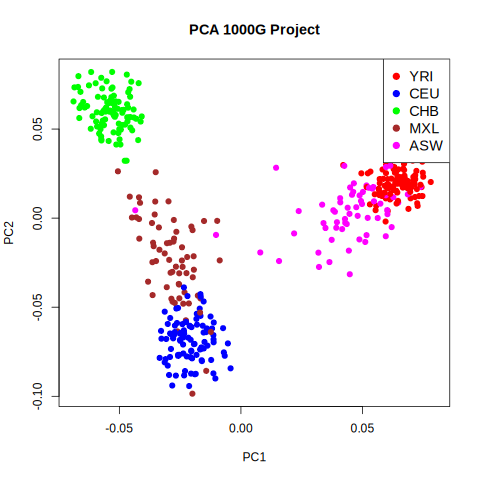

In [8]:
%%R
C <- as.matrix(read.table("pca_1000G.cov"))
e <- eigen(C)

pops <- readLines("1000G_bam_list.txt")
pops <- sapply(strsplit(pops, "\\."), function(x) x[6])

mycolor <- rep("red", length(pops))
mycolor[pops == "CEU"] <- "blue"
mycolor[pops == "CHB"] <- "green"
mycolor[pops == "MXL"] <- "brown"
mycolor[pops == "ASW"] <- "magenta"

plot(e$vectors[, 1:2],
     xlab = "PC1", ylab = "PC2",
     main = "PCA 1000G Project",
     col = mycolor, pch = 19)
legend("topright",
       legend = c("YRI", "CEU", "CHB", "MXL", "ASW"),
       col = c("red", "blue", "green", "brown", "magenta"),
       pch = 19, cex = 1.2)

## 9. Run NGSadmix for Admixture Analysis

`NGSadmix` estimates individual ancestry proportions (the **Q matrix**) directly from genotype likelihoods, without requiring hard genotype calls.

| Flag | Meaning |
|---|---|
| `-likes` | Beagle-format genotype likelihood file |
| `-K 3` | Number of ancestral populations to fit |
| `-minMaf 0.05` | Minimum minor allele frequency |
| `-seed 1` | Random seed for reproducibility |
| `-o 1000G` | Output prefix |

The main output is `1000G.qopt`, which contains the admixture proportions for each individual.

In [9]:
!NGSadmix -likes 1000G.beagle.gz -K 3 -minMaf 0.05 -seed 1 -o 1000G

Input: lname=1000G.beagle.gz nPop=3, fname=(null) qname=(null) outfiles=1000G
Setup: seed=1 nThreads=1 method=1
Convergence: maxIter=2000 tol=0.000010 tolLike50=0.100000 dymBound=0
Filters: misTol=0.050000 minMaf=0.050000 minLrt=0.000000 minInd=0
Input file has dim: nsites=1306 nind=435
Input file has dim (AFTER filtering): nsites=1306 nind=435
iter[start] like is=725129.713622
iter[50] like is=-454493.026878 thres=0.000841
iter[100] like is=-454474.788034 thres=0.000032
EM accelerated has reached convergence with tol 0.000010
best like=-454474.752968 after 115 iterations
	-> Dumpedfiles are: 1000G.log
	-> Dumpedfiles are: 1000G.qopt
	-> Dumpedfiles are: 1000G.fopt.gz
	[ALL done] cpu-time used =  21.41 sec
	[ALL done] walltime used =  23.00 sec


### 9.1 Inspect the NGSadmix output

The `.qopt` file contains one row per individual and `K` columns (one per ancestral population).

In [10]:
!ls -lh 1000G.qopt

-rw------- 1 root root 30K Sep 27 14:46 1000G.qopt


In [11]:
!head 1000G.qopt

0.00543120337380969750 0.03047764250291678037 0.96409115412327339723 
0.39746657097866411323 0.59699325992555196674 0.00554016909578402498 
0.00291473396727394071 0.00000000099999999999 0.99708526503272598696 
0.89272766803245084954 0.00000008404621942802 0.10727224792132973585 
0.87148184717709176184 0.12851815182290812767 0.00000000099999999997 
0.81529873054609225402 0.15780315987658605215 0.02689810957732174240 
0.83248589650022153386 0.07729402969534844570 0.09022007380443013147 
0.71004516603356415683 0.00000000099999999998 0.28995483296643576043 
0.09294217159488990521 0.90705782740511009532 0.00000000099999999997 
0.00000000099999999994 0.00000000099999999994 0.99999999799999994554 


## 10. Plot the Admixture Bar Plot in R

We use the `visFuns.R` helper script from the `evalAdmix` GitHub repository to order the individuals by population and produce a clean bar plot.

The `orderInds()` function sorts individuals according to a specified population order, and `barplot()` displays the admixture proportions as a stacked bar chart.

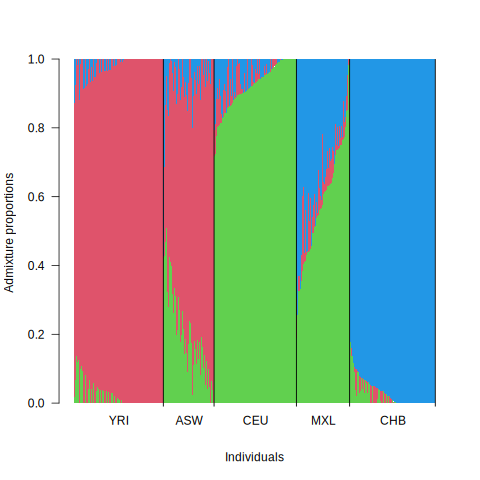

In [12]:
%%R
pops <- readLines("1000G_bam_list.txt")
pops <- sapply(strsplit(pops, "\\."), function(x) x[6])

source("https://raw.githubusercontent.com/GenisGE/evalAdmix/master/visFuns.R")

qopts <- read.table("1000G.qopt")

ord <- orderInds(pop = pops, q = qopts,
                 popord = c("YRI", "ASW", "CEU", "MXL", "CHB"))

barplot(t(qopts)[, ord],
        col = c(3, 2, 4),
        las = 2,
        xlab = "Individuals",
        ylab = "Admixture proportions",
        space = 0, border = NA)

text(sort(tapply(1:length(pops), pops[ord], mean)),
     -0.05, unique(pops[ord]), xpd = NA)

abline(v = cumsum(sapply(unique(pops[ord]),
                         function(x) { sum(pops[ord] == x) })),
       col = 1, lwd = 1.2)

## 11. Summary

In this notebook we:

✅ Installed **Conda**, **ANGSD**, and **pcangsd** in Google Colab.  
✅ Mounted **Google Drive** to access the BAM files.  
✅ Rebuilt the BAM file list with Colab-compatible paths.  
✅ Computed genotype likelihoods with **ANGSD** (`1000G.beagle.gz`).  
✅ Ran **PCA** with **pcangsd** and visualized PC1 vs PC2 in R.  
✅ Ran **NGSadmix** with K = 3 and plotted the admixture bar plot in R.

### Next steps

- Try different values of **K** in NGSadmix (e.g. K = 2, 4, 5) and compare the bar plots.
- Compute **Fst** between CEU and YRI with `realSFS` and plot it along the genome.
- Run the **D-statistic** (ABBA-BABA) test with `angsd -doAbbababa 1`.

### References

- Korneliussen, T. S., Albrechtsen, A., & Nielsen, R. (2014). *ANGSD: Analysis of Next Generation Sequencing Data.* BMC Bioinformatics.
- Meisner, J., & Albrechtsen, A. (2018). *Inferring population structure and admixture proportions in low-depth NGS data.* Genetics.
- Skotte, L., Korneliussen, T. S., & Albrechtsen, A. (2013). *Estimating individual admixture proportions from next generation sequencing data.* Genetics.

In [13]:
!jupyter nbconvert --to html /content/drive/MyDrive/PopGen_PopStructure/ANGSD_Lab_GoogleColab.ipynb

[NbConvertApp] Converting notebook /content/drive/MyDrive/PopGen_PopStructure/ANGSD_Lab_GoogleColab.ipynb to html
/usr/local/share/jupyter/nbconvert/templates/base/display_priority.j2:32: UserWarning: Your element with mimetype(s) dict_keys(['application/vnd.colab-display-data+json']) is not able to be represented.
  {%- elif type == 'text/vnd.mermaid' -%}
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 467506 bytes to /content/drive/MyDrive/PopGen_PopStructure/ANGSD_Lab_GoogleColab.html
